In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("climate_data_2010_2025.csv")

In [3]:
df.head()

,Date,Latitude,Longitude,Max_Temperature,Min_Temperature,Rainfall
0,2010-01-01,8.5,77.5,32.04,22.81,0.0
1,2010-01-01,8.5,78.5,31.11,22.65,0.0
2,2010-01-01,9.5,76.5,31.27,21.50,0.0
3,2010-01-01,9.5,77.5,30.67,21.35,0.0
4,2010-01-01,9.5,78.5,29.44,20.85,0.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1928989 entries, 329 to 1929319
Data columns (total 8 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Date              datetime64[ns]
 1   Latitude          float64       
 2   Longitude         float64       
 3   Max_Temperature   float64       
 4   Min_Temperature   float64       
 5   Rainfall          float64       
 6   MaxTemp_Next_Day  float64       
 7   MaxTemp_Lag1      float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 132.5 MB


In [14]:
df.shape

(1928989, 8)

In [15]:
df.describe()

,Date,Latitude,Longitude,Max_Temperature,Min_Temperature,Rainfall,MaxTemp_Next_Day,MaxTemp_Lag1
count,1928989,1.928989e+06,1.928989e+06,1.928989e+06,1.928989e+06,1.928989e+06,1.928989e+06,1.928989e+06
mean,2018-01-02 13:25:31.199398912,2.360235e+01,7.997013e+01,3.095613e+01,1.905384e+01,3.422121e+00,3.095609e+01,3.095615e+01
min,2010-01-02 00:00:00,8.500000e+00,6.850000e+01,2.015030e+00,-8.820000e+00,0.000000e+00,2.015030e+00,2.015030e+00
25%,2014-01-04 00:00:00,1.950000e+01,7.550000e+01,2.811052e+01,1.468526e+01,0.000000e+00,2.811065e+01,2.811019e+01
50%,2018-01-02 00:00:00,2.450000e+01,7.850000e+01,3.134000e+01,2.087958e+01,0.000000e+00,3.134000e+01,3.134000e+01
75%,2022-01-02 00:00:00,2.750000e+01,8.350000e+01,3.450449e+01,2.415933e+01,1.695291e+00,3.450449e+01,3.450449e+01
max,2025-12-30 00:00:00,3.650000e+01,9.750000e+01,4.877099e+01,3.320000e+01,8.069304e+02,4.877099e+01,4.877099e+01
std,NaN,6.021265e+00,6.271859e+00,5.927622e+00,6.538782e+00,1.040381e+01,5.927708e+00,5.927500e+00


In [4]:
df["Date"] = pd.to_datetime(df["Date"])

In [6]:
print(df.shape)
print(df.head())

(1929651, 6)
        Date  Latitude  Longitude  Max_Temperature  Min_Temperature  Rainfall
0 2010-01-01       8.5       77.5            32.04            22.81       0.0
1 2010-01-01       8.5       78.5            31.11            22.65       0.0
2 2010-01-01       9.5       76.5            31.27            21.50       0.0
3 2010-01-01       9.5       77.5            30.67            21.35       0.0
4 2010-01-01       9.5       78.5            29.44            20.85       0.0


In [7]:
df = df.sort_values(["Latitude", "Longitude", "Date"])

In [8]:
df["MaxTemp_Next_Day"] = (
    df.groupby(["Latitude", "Longitude"])["Max_Temperature"]
      .shift(-1)
)

In [9]:
df["MaxTemp_Lag1"] = (
    df.groupby(["Latitude", "Longitude"])["Max_Temperature"]
      .shift(1)
)

In [10]:
df = df.dropna()
print(df.shape)
print(df.isnull().sum())

(1928989, 8)
Date                0
Latitude            0
Longitude           0
Max_Temperature     0
Min_Temperature     0
Rainfall            0
MaxTemp_Next_Day    0
MaxTemp_Lag1        0
dtype: int64


In [12]:
df.columns

Index(['Date', 'Latitude', 'Longitude', 'Max_Temperature', 'Min_Temperature',
       'Rainfall', 'MaxTemp_Next_Day', 'MaxTemp_Lag1'],
      dtype='object')

In [16]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df["Season"] = df["Month"].map({
    12: 0, 1: 0, 2: 0,   # Winter
    3: 1, 4: 1, 5: 1,    # Summer
    6: 2, 7: 2, 8: 2,    # Monsoon
    9: 3, 10: 3, 11: 3   # Post-Monsoon
})

In [17]:
corr = df.select_dtypes(include=["number"]).corr()

print(corr)

                  Latitude  Longitude  Max_Temperature  Min_Temperature  \
Latitude          1.000000   0.078156        -0.349133        -0.401202   
Longitude         0.078156   1.000000        -0.087576         0.025437   
Max_Temperature  -0.349133  -0.087576         1.000000         0.821296   
Min_Temperature  -0.401202   0.025437         0.821296         1.000000   
Rainfall         -0.046766   0.097703        -0.074169         0.161152   
MaxTemp_Next_Day -0.349139  -0.087597         0.974690         0.807130   
MaxTemp_Lag1     -0.349135  -0.087543         0.974690         0.830551   
Year              0.001592   0.001938        -0.014278         0.018951   
Month            -0.000011   0.000019        -0.035462         0.100767   
Season           -0.000243   0.000100         0.247913         0.444568   

                  Rainfall  MaxTemp_Next_Day  MaxTemp_Lag1      Year  \
Latitude         -0.046766         -0.349139     -0.349135  0.001592   
Longitude         0.097703    

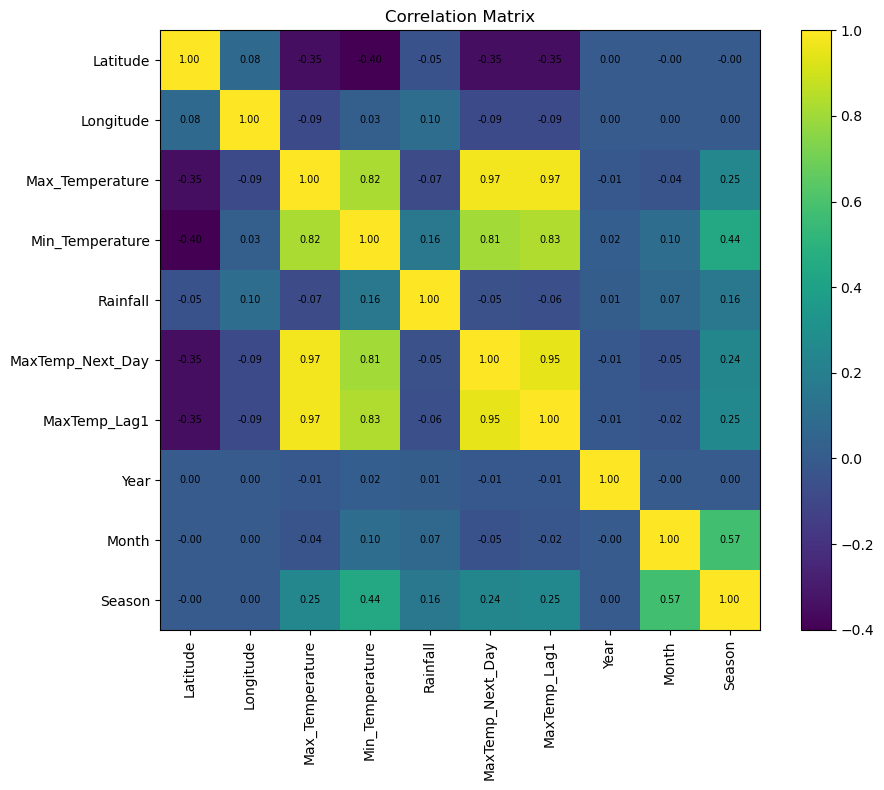

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(corr, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Values inside cells
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

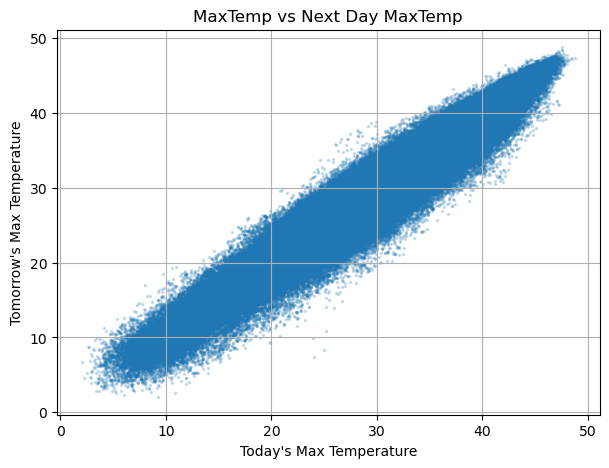

In [19]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Max_Temperature"],
    df["MaxTemp_Next_Day"],
    s=2,
    alpha=0.2
)

plt.xlabel("Today's Max Temperature")
plt.ylabel("Tomorrow's Max Temperature")
plt.title("MaxTemp vs Next Day MaxTemp")
plt.grid(True)

plt.show()

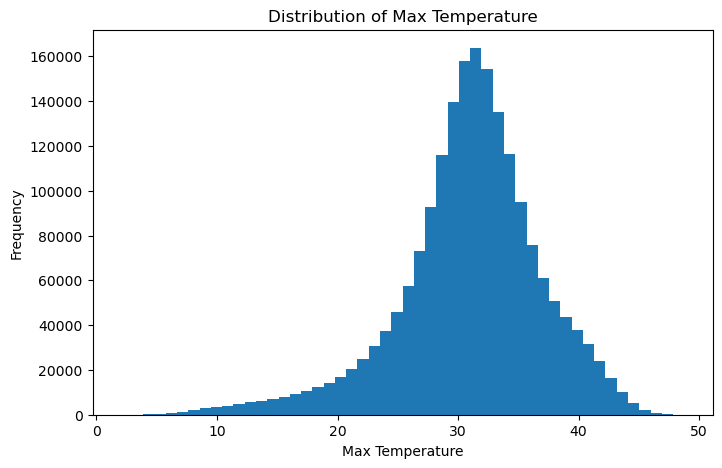

In [20]:
plt.figure(figsize=(8,5))

plt.hist(df["Max_Temperature"], bins=50)

plt.xlabel("Max Temperature")
plt.ylabel("Frequency")
plt.title("Distribution of Max Temperature")

plt.show()

In [21]:
df["Temp_Change"] = df["Max_Temperature"] - df["Min_Temperature"]

In [27]:
features = [
    "Latitude",
    "Longitude",
    "Max_Temperature",
    "Min_Temperature",
    "Rainfall",
    "MaxTemp_Lag1",
    "Temp_Change",
    "Year",
    "Month",
    "Season"
]

In [28]:
train_df = df[df["Year"] <= 2023]
test_df = df[df["Year"] >= 2024]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(X_train.shape)
print(X_test.shape)

(1687538, 10)
(241451, 10)


In [29]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

In [30]:
model.fit(X_train, y_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,8
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² :", r2_score(y_test, y_pred))

MAE : 0.9424621293717871
RMSE: 1.3001601943924952
R² : 0.947402307284285
